## 4 — GLMERStan Climate  
Bayesian Multilevel Regression + Poststratification  
Outcome: `happening_bin` (Do you think global warming is happening? Yes=1 / No=0)

**Howe (2015) 3-level architecture** (Gelman & Hill style, MAP via L-BFGS-B):  
- Individual: `logit(p_i) = γ₀ + α_gender + α_race + α_educ + α_state`  
- State: `α_state[s] ~ N(α_region[div[s]] + γ_carbon·co2_std[s] + γ_pres·pres_std[s], σ_state²)`  
- Region: `α_region[r] ~ N(0, σ_region²)` — 9 Census divisions

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.special import expit
from scipy.optimize import minimize

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"

SEED = 42

### 1. Load data

In [2]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                        dtype={"state_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                        dtype={"state_fips": str})

print(f"Survey raw:   {survey_raw.shape}")
print(f"Poststrat:    {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey raw:   (1200, 38)
Poststrat:    (1632, 9) | 51 states


### 2. Prep survey data  
 Drop Don't-Know responses for `happening_bin`

In [3]:
DEMOG = ["gender", "race4", "educ_category", "state_fips"]

# Drop DK (NaN happening_bin)
survey = survey_raw.dropna(subset=["happening_bin"]).copy()
survey["happening_bin"] = survey["happening_bin"].astype(int)

# educ_category as string so bambi treats it as categorical grouping factor
survey["educ_category"] = survey["educ_category"].astype(str)
ps_frame["educ_category"] = ps_frame["educ_category"].astype(str)

print(f"Respondents after dropping DK: {len(survey):,}  "
      f"({survey['happening_bin'].mean()*100:.1f}% Yes)")
print()
print("Level counts in survey:")
for c in DEMOG:
    print(f"  {c}: {sorted(survey[c].unique().tolist())}")

Respondents after dropping DK: 1,010  (68.1% Yes)

Level counts in survey:
  gender: ['Female', 'Male']
  race4: ['Black', 'Hispanic', 'Other', 'White']
  educ_category: ['1', '2', '3', '4']
  state_fips: ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56']


In [4]:
# ── State-level covariates (Howe 2015: carbon + presidential vote + ACS extras) ─
county_raw = pd.read_csv(DATA_DIR + "poststrat_county.csv", dtype={"state_fips": str})

state_cov = (
    county_raw.groupby("state_fips")
    .apply(lambda g: pd.Series({
        "co2_per_capita":      np.average(g["co2_per_capita"],      weights=g["N_rounded"]),
        "dem_share_two_party": np.average(g["dem_share_two_party"], weights=g["N_rounded"]),
    }), include_groups=False)
    .reset_index()
)
# Impute 4 states with missing county data (CT, AK, HI, SD) using national mean
state_cov["co2_per_capita"].fillna(state_cov["co2_per_capita"].mean(), inplace=True)
state_cov["dem_share_two_party"].fillna(state_cov["dem_share_two_party"].mean(), inplace=True)

# ACS state-level extras: % drive alone, % same-sex households
acs_extra = pd.read_csv(DATA_DIR + "acs_state_extra_covariates.csv",
                        dtype={"state_fips": str})
state_cov = state_cov.merge(acs_extra, on="state_fips")

# Division (Census division 1–9) from poststrat_state
state_div = ps_frame.groupby("state_fips")["division"].first().reset_index()
state_cov = (state_cov.merge(state_div, on="state_fips")
                       .sort_values("state_fips").reset_index(drop=True))

print(f"State covariates: {state_cov.shape} — columns: {state_cov.columns.tolist()}")
print(state_cov[["state_fips","co2_per_capita","dem_share_two_party",
                  "pct_drive_alone","pct_samesex_hh","division"]].head(8).to_string(index=False))

State covariates: (51, 6) — columns: ['state_fips', 'co2_per_capita', 'dem_share_two_party', 'pct_drive_alone', 'pct_samesex_hh', 'division']
state_fips  co2_per_capita  dem_share_two_party  pct_drive_alone  pct_samesex_hh  division
        01       25.083814             0.352701         0.814562        0.005769         6
        02       35.150822             0.478900         0.655835        0.006742         9
        04       11.525334             0.472041         0.685313        0.010205         8
        05       21.838944             0.346660         0.796665        0.006204         7
        06        9.129450             0.602899         0.670701        0.011608         9
        08       15.616872             0.559170         0.668042        0.011163         8
        09       20.242029             0.575048         0.706023        0.009642         1
        10       13.999585             0.580504         0.734335        0.012486         5


### 3. Fit MAP model — Howe (2015) 3-level architecture
Maximises the penalised log-posterior via L-BFGS-B (equivalent to Stan's `optimizing()`).

**Individual level:** `logit(p_i) = γ₀ + α_gender[g] + α_race[r] + α_educ[e] + α_state[s]`

**State level (informative prior with 4 state-level covariates):**
`α_state[s] ~ N(α_region[div[s]] + γ_carbon·co2 + γ_pres·pres + γ_drive·drive + γ_samesex·samesex, σ_state²)`

**Region level** (9 Census divisions): `α_region[r] ~ N(0, σ_region²)`

All 4 covariates standardised (z-score). Priors: Intercept ~ N(0, 1.5²), γ ~ N(0, 1), σ ~ HalfNormal(2.5).

In [5]:
from scipy.special import expit
from scipy.optimize import minimize

# ── Encode categorical variables as integer indices ───────────────────────────
gender_cats = sorted(survey["gender"].unique())
state_cats  = sorted(survey["state_fips"].unique())
race_cats   = sorted(survey["race4"].unique())
educ_cats   = sorted(survey["educ_category"].unique())
div_cats    = sorted(state_cov["division"].unique())        # 9 Census divisions

g_idx = pd.Categorical(survey["gender"],          categories=gender_cats).codes
s_idx = pd.Categorical(survey["state_fips"],      categories=state_cats).codes
r_idx = pd.Categorical(survey["race4"],           categories=race_cats).codes
e_idx = pd.Categorical(survey["educ_category"],   categories=educ_cats).codes
y     = survey["happening_bin"].values.astype(float)

n_g, n_s, n_r, n_e = len(gender_cats), len(state_cats), len(race_cats), len(educ_cats)
n_div = len(div_cats)   # 9

# ── State-level covariate arrays (ordered to match state_cats) ────────────────
sc = state_cov.set_index("state_fips").loc[state_cats].reset_index()

def _std(x):
    return (x - x.mean()) / x.std()

co2_std    = _std(sc["co2_per_capita"].values)
pres_std   = _std(sc["dem_share_two_party"].values)
drive_std  = _std(sc["pct_drive_alone"].values)
samesex_std = _std(sc["pct_samesex_hh"].values)

# Division index for each state (0-indexed, pointing into α_region array)
state_div_idx = pd.Categorical(
    sc["division"].astype(str),
    categories=[str(d) for d in div_cats]
).codes

print(f"Group levels — gender:{n_g}  state:{n_s}  race:{n_r}  educ:{n_e}  divisions:{n_div}")
print(f"Total params: 1+5+4 + {n_g}+{n_r}+{n_e}+{n_div}+{n_s} = {1+5+4+n_g+n_r+n_e+n_div+n_s}")

Group levels — gender:2  state:51  race:4  educ:4  divisions:9
Total params: 1+5+4 + 2+4+4+9+51 = 80


In [6]:
def _unpack(params):
    gamma0        = params[0]
    sigma         = np.exp(params[1:6])   # [σ_gender, σ_race, σ_educ, σ_state, σ_region]
    gc, gp, gd, gs = params[6], params[7], params[8], params[9]   # γ covariates
    off = 10
    u_g   = params[off:off+n_g];   off += n_g
    u_r   = params[off:off+n_r];   off += n_r
    u_e   = params[off:off+n_e];   off += n_e
    u_reg = params[off:off+n_div]; off += n_div
    u_s   = params[off:off+n_s]
    return gamma0, sigma, gc, gp, gd, gs, u_g, u_r, u_e, u_reg, u_s

def neg_log_posterior(params):
    gamma0, sigma, gc, gp, gd, gs, u_g, u_r, u_e, u_reg, u_s = _unpack(params)
    sig_g, sig_r, sig_e, sig_s, sig_reg = sigma

    # Likelihood
    eta = gamma0 + u_g[g_idx] + u_r[r_idx] + u_e[e_idx] + u_s[s_idx]
    ll  = np.sum(y * eta - np.logaddexp(0.0, eta))

    # State prior: α_state[s] ~ N(μ_state[s], σ_state²)
    mu_s = (u_reg[state_div_idx]
            + gc * co2_std + gp * pres_std
            + gd * drive_std + gs * samesex_std)
    lp_s   = -0.5 * np.sum((u_s - mu_s)**2) / sig_s**2   - n_s   * np.log(sig_s)

    # Region prior: α_region[r] ~ N(0, σ_region²)
    lp_reg = -0.5 * np.sum(u_reg**2) / sig_reg**2         - n_div * np.log(sig_reg)

    # Individual random effects
    lp_g   = -0.5 * np.sum(u_g**2) / sig_g**2  - n_g * np.log(sig_g)
    lp_r   = -0.5 * np.sum(u_r**2) / sig_r**2  - n_r * np.log(sig_r)
    lp_e   = -0.5 * np.sum(u_e**2) / sig_e**2  - n_e * np.log(sig_e)

    # Hyperpriors
    lp_int   = -0.5 * gamma0**2 / 1.5**2
    lp_gamma = -0.5 * gc**2 - 0.5 * gp**2 - 0.5 * gd**2 - 0.5 * gs**2
    lp_sigma = np.sum(-0.5 * sigma**2 / 2.5**2 + params[1:6])  # HalfNormal(2.5) + Jacobian

    return -(ll + lp_s + lp_reg + lp_g + lp_r + lp_e + lp_int + lp_gamma + lp_sigma)

N_PARAMS = 1 + 5 + 4 + n_g + n_r + n_e + n_div + n_s   # 80
x0       = np.zeros(N_PARAMS)
x0[1:6]  = np.log(0.5)   # warm start: σ = 0.5

start = time.time()
res   = minimize(neg_log_posterior, x0, method="L-BFGS-B",
                 options={"maxiter": 20_000, "ftol": 1e-9, "gtol": 1e-6})
elapsed = time.time() - start

gamma0_fit, sigma_fit, gc_fit, gp_fit, gd_fit, gs_fit, u_g_fit, u_r_fit, u_e_fit, u_reg_fit, u_s_fit = _unpack(res.x)
intercept_fit = gamma0_fit   # alias used by downstream cells

print(f"Converged : {res.success}  |  iterations: {res.nit}  |  {elapsed:.1f}s")
print(f"Intercept : {gamma0_fit:.3f}  (baseline prob {expit(gamma0_fit)*100:.1f}%)")
print(f"γ_carbon  : {gc_fit:.3f}   γ_pres : {gp_fit:.3f}   γ_drive : {gd_fit:.3f}   γ_samesex : {gs_fit:.3f}")
print(f"σ — gender:{sigma_fit[0]:.3f}  race:{sigma_fit[1]:.3f}  educ:{sigma_fit[2]:.3f}  "
      f"state:{sigma_fit[3]:.3f}  region:{sigma_fit[4]:.3f}")
print(f"\nRegion effects (divisions 1–9): {np.round(u_reg_fit, 3)}")
print(f"State effect range: [{u_s_fit.min():.3f}, {u_s_fit.max():.3f}]")

Converged : False  |  iterations: 112  |  1.8s
Intercept : 0.962  (baseline prob 72.3%)
γ_carbon  : -0.077   γ_pres : 0.220   γ_drive : 0.050   γ_samesex : -0.105
σ — gender:0.423  race:0.262  educ:0.276  state:0.000  region:0.079

Region effects (divisions 1–9): [ 0.028  0.243 -0.434  0.118  0.185 -0.252 -0.213  0.139  0.114]
State effect range: [-0.522, 0.547]


### 4. Fitted random effects

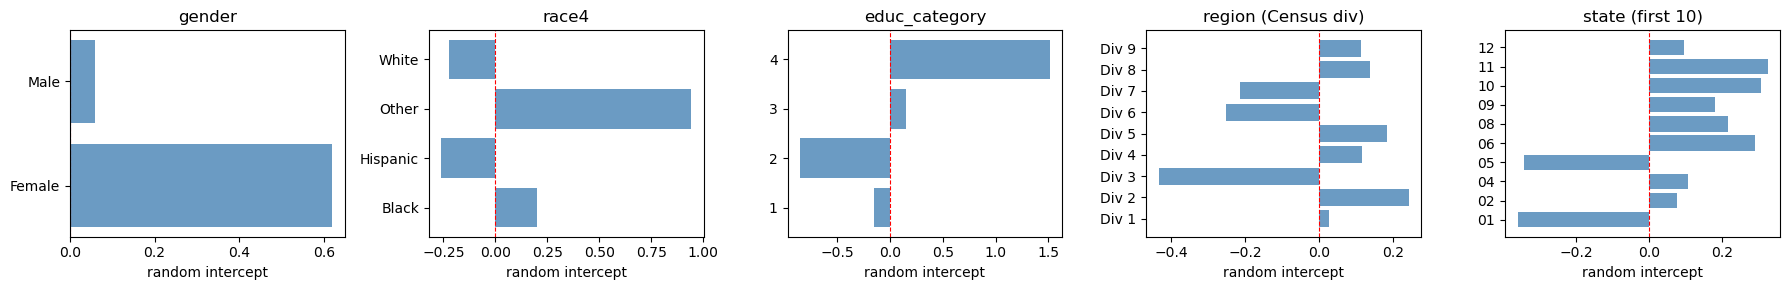

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
div_labels = [f"Div {d}" for d in div_cats]
for ax, (cats, u_fit, label) in zip(axes, [
    (gender_cats,      u_g_fit,   "gender"),
    (race_cats,        u_r_fit,   "race4"),
    (educ_cats,        u_e_fit,   "educ_category"),
    (div_labels,       u_reg_fit, "region (Census div)"),
    (state_cats[:10],  u_s_fit[:10], "state (first 10)"),
]):
    ax.barh(cats, u_fit, color="steelblue", alpha=0.8)
    ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("random intercept")
plt.tight_layout()
plt.show()

### 5. Predict on the poststrat frame  
Map each ACS demographic cell to its fitted random effects and compute predicted probability.

In [8]:
ps_g = pd.Categorical(ps_frame["gender"],          categories=gender_cats).codes
ps_s = pd.Categorical(ps_frame["state_fips"],      categories=state_cats).codes
ps_r = pd.Categorical(ps_frame["race4"],           categories=race_cats).codes
ps_e = pd.Categorical(ps_frame["educ_category"],   categories=educ_cats).codes

eta_ps = intercept_fit + u_g_fit[ps_g] + u_s_fit[ps_s] + u_r_fit[ps_r] + u_e_fit[ps_e]
ps_frame["predicted_prob"] = expit(eta_ps)

print(f"Predicted probabilities: "
      f"min={ps_frame['predicted_prob'].min():.3f}  "
      f"mean={ps_frame['predicted_prob'].mean():.3f}  "
      f"max={ps_frame['predicted_prob'].max():.3f}")
ps_frame[["state_fips","gender","race4","educ_category",
          "N_rounded","predicted_prob"]].head(8)

Predicted probabilities: min=0.351  mean=0.795  max=0.990


,state_fips,gender,race4,educ_category,N_rounded,predicted_prob
0,01,Female,Black,1,61051,0.780111
1,01,Female,Black,2,171337,0.637577
2,01,Female,Black,3,196091,0.827911
3,01,Female,Black,4,116020,0.949464
4,01,Female,Hispanic,1,22147,0.691290
5,01,Female,Hispanic,2,21955,0.526153
6,01,Female,Hispanic,3,21228,0.752267
7,01,Female,Hispanic,4,17191,0.922231


### 6. Poststratification  
Weighted average of cell-level predicted probabilities, weighted by ACS population counts.

In [9]:
result = (
    ps_frame
    .groupby("state_fips")
    .apply(lambda g: np.average(g["predicted_prob"], weights=g["N_rounded"]),
           include_groups=False)
    .reset_index(name="happening_estimate")
)

# Merge state names for readability
STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National weighted estimate: {np.average(result['happening_estimate']):.3f}")
print()
print("Top 10 states (highest % believing GW is happening):")
print(result.head(10).to_string(index=False))
print()
print("Bottom 10 states:")
print(result.tail(10).to_string(index=False))

National weighted estimate: 0.775

Top 10 states (highest % believing GW is happening):
state_fips  happening_estimate           state_name
        11            0.894381 District of Columbia
        24            0.870589             Maryland
        15            0.860714               Hawaii
        34            0.845724           New Jersey
        51            0.841604             Virginia
        36            0.835370             New York
        06            0.830732           California
        25            0.829072        Massachusetts
        53            0.827825           Washington
        08            0.824468             Colorado

Bottom 10 states:
state_fips  happening_estimate    state_name
        01            0.702125       Alabama
        47            0.695945     Tennessee
        54            0.695287 West Virginia
        40            0.693945      Oklahoma
        05            0.688964      Arkansas
        39            0.688773          Ohio
      

### 7. Visualise state estimates

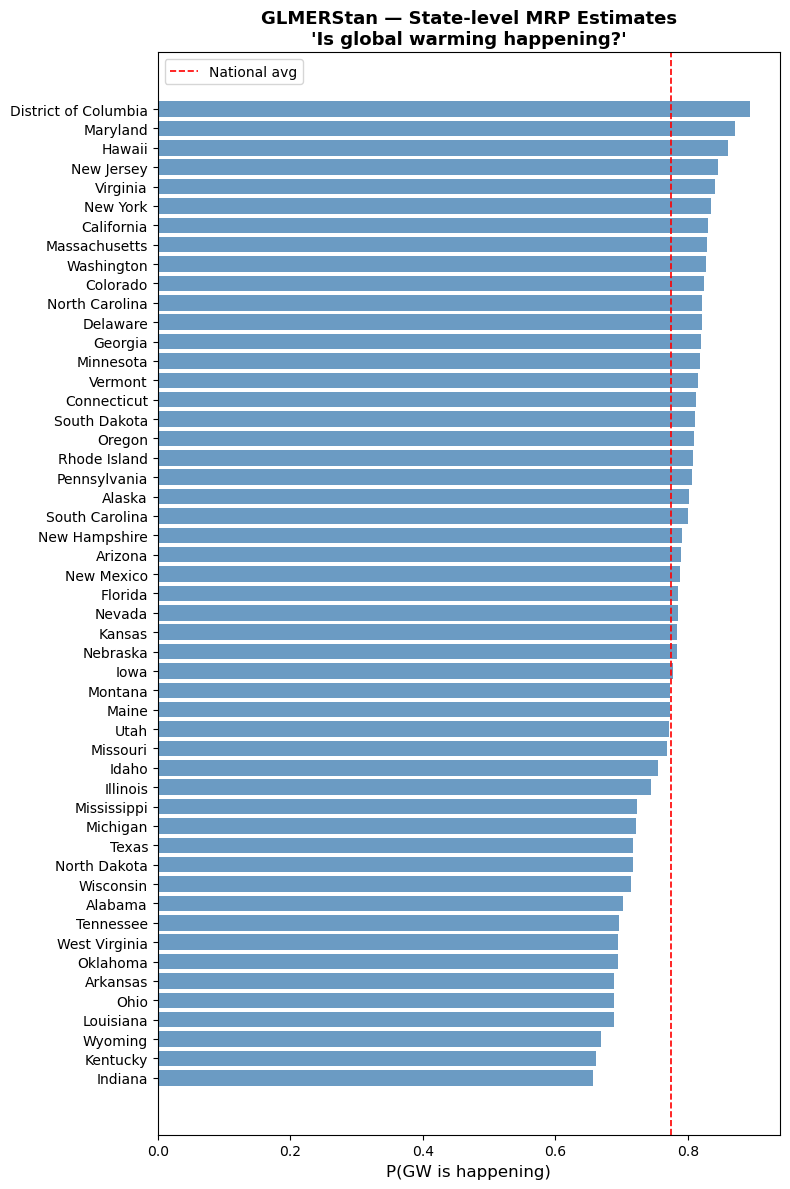

In [10]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="steelblue", alpha=0.8)
ax.axvline(np.average(result["happening_estimate"]), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("GLMERStan — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 8. Save results

In [11]:
OUT = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/glmerstan_mrp_state_estimates.csv"
result[["state_fips","state_name","happening_estimate"]].rename(columns={"happening_estimate":"estimate"}).to_csv(OUT, index=False)
print(f"Saved → {OUT}")
print(result[["state_fips","state_name","happening_estimate"]].to_string(index=False))

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/glmerstan_mrp_state_estimates.csv
state_fips           state_name  happening_estimate
        11 District of Columbia            0.894381
        24             Maryland            0.870589
        15               Hawaii            0.860714
        34           New Jersey            0.845724
        51             Virginia            0.841604
        36             New York            0.835370
        06           California            0.830732
        25        Massachusetts            0.829072
        53           Washington            0.827825
        08             Colorado            0.824468
        37       North Carolina            0.821767
        10             Delaware            0.821309
        13              Georgia            0.819823
        27            Minnesota            0.817945
        50              Vermont            0.815118
        09          Connecticut            0.812018